## 📑 Leveraged Buyout (LBO) Modeling Engine

In [78]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import newton

### 1. Data Collection

In [ ]:
ticker = "TOTS3.SA"  # Stock ticker symbol

holding_period = 5  # Investment horizon (y)

entry_ebitda_multiple = 10  # Entry valuation multiple (EV / EBITDA)
exit_ebitda_multiple = 11  # Exit valuation multiple (EV / EBITDA)

leverage_ratio = 0.70  # Percentage of debt financing
interest_rate = 0.10  # Annual debt interest rate

revenue_growth = [0.08, 0.07, 0.06, 0.05, 0.05]  # Annual revenue growth assumptions

ebitda_margin = 0.32  # EBITDA margin assumption
capex_percent_revenue = 0.04  # Capex as percentage of revenue
nwc_percent_revenue = 0.02  # Net working capital as percentage of revenue

tax_rate = 0.25  # Corporate tax rate
mandatory_amortization = 0.20  # Mandatory annual debt repayment

### 2. Financial Statement Collection

In [80]:
empresa = yf.Ticker(ticker)

income_statement = empresa.financials  # Annual income statement
balance_sheet = empresa.balance_sheet  # Annual balance sheet
cashflow_statement = empresa.cashflow  # Annual cash flow statement

income_statement.columns = pd.to_datetime(income_statement.columns).strftime("%d/%m/%Y")  # Format dates
balance_sheet.columns = pd.to_datetime(balance_sheet.columns).strftime("%d/%m/%Y")  # Format dates
cashflow_statement.columns = pd.to_datetime(cashflow_statement.columns).strftime("%d/%m/%Y")  # Format dates

### 3. Historical Financial Extraction

In [81]:
revenue = income_statement.loc["Total Revenue"].iloc[0]  # Latest revenue

ebitda = income_statement.loc["EBITDA"].iloc[0] if "EBITDA" in income_statement.index else income_statement.loc["EBIT"].iloc[0]  # EBITDA fallback

cash = balance_sheet.loc["Cash And Cash Equivalents"].iloc[0] if "Cash And Cash Equivalents" in balance_sheet.index else 0  # Cash position

debt = balance_sheet.loc["Total Debt"].iloc[0] if "Total Debt" in balance_sheet.index else 0  # Debt position

shares_outstanding = empresa.info.get("sharesOutstanding", np.nan)  # Shares outstanding

current_price = empresa.info.get("currentPrice", np.nan)  # Current stock price

### 4. Entry Valuation

In [82]:
enterprise_value_entry = ebitda * entry_ebitda_multiple  # Entry enterprise value

equity_value_entry = enterprise_value_entry - debt + cash  # Entry equity value

sponsor_equity = equity_value_entry * (1 - leverage_ratio)  # Sponsor equity contribution

new_debt = enterprise_value_entry * leverage_ratio  # LBO debt financing


### 5. Forecast Model

In [83]:
forecast_years = []
forecast_revenue = []
forecast_ebitda = []
forecast_capex = []
forecast_nwc = []
forecast_fcf = []
forecast_debt = []
forecast_interest = []

remaining_debt = new_debt

current_revenue = revenue

### 6. Projection Engine

In [84]:
for year in range(holding_period):

    current_revenue = current_revenue * (1 + revenue_growth[year])  # Revenue projection

    projected_ebitda = current_revenue * ebitda_margin  # EBITDA projection

    projected_capex = current_revenue * capex_percent_revenue  # Capex projection

    projected_nwc = current_revenue * nwc_percent_revenue  # Working capital projection

    projected_interest = remaining_debt * interest_rate  # Interest expense

    taxes = max((projected_ebitda - projected_interest), 0) * tax_rate  # Tax calculation

    free_cash_flow = (
        projected_ebitda
        - projected_capex
        - projected_nwc
        - projected_interest
        - taxes
    )  # Levered free cash flow

    debt_paydown = max(free_cash_flow * mandatory_amortization, 0)  # Debt amortization

    remaining_debt = max(remaining_debt - debt_paydown, 0)  # Remaining debt balance

    forecast_years.append(year + 1)
    forecast_revenue.append(current_revenue)
    forecast_ebitda.append(projected_ebitda)
    forecast_capex.append(projected_capex)
    forecast_nwc.append(projected_nwc)
    forecast_fcf.append(free_cash_flow)
    forecast_debt.append(remaining_debt)
    forecast_interest.append(projected_interest)

### 7. Forecast DataFrame

In [85]:
forecast_df = pd.DataFrame({
    "Year": forecast_years,
    "Revenue": forecast_revenue,
    "EBITDA": forecast_ebitda,
    "Capex": forecast_capex,
    "NWC": forecast_nwc,
    "Interest": forecast_interest,
    "FCF": forecast_fcf,
    "Remaining Debt": forecast_debt
})

forecast_df

,Year,Revenue,EBITDA,Capex,NWC,Interest,FCF,Remaining Debt
0,1,6.233616e+09,1.994757e+09,2.493447e+08,1.246723e+08,1.151524e+09,2.584081e+08,1.146356e+10
1,2,6.669970e+09,2.134390e+09,2.667988e+08,1.333994e+08,1.146356e+09,3.408278e+08,1.139539e+10
2,3,7.070168e+09,2.262454e+09,2.828067e+08,1.414034e+08,1.139539e+09,4.179759e+08,1.131180e+10
3,4,7.423676e+09,2.375576e+09,2.969470e+08,1.484735e+08,1.131180e+09,4.878770e+08,1.121422e+10
4,5,7.794860e+09,2.494355e+09,3.117944e+08,1.558972e+08,1.121422e+09,5.620083e+08,1.110182e+10


### 8. Exit Valuation

In [86]:
exit_ebitda = forecast_ebitda[-1]  # Final year EBITDA

enterprise_value_exit = exit_ebitda * exit_ebitda_multiple  # Exit enterprise value

remaining_debt_exit = forecast_debt[-1]  # Debt remaining at exit

exit_equity_value = enterprise_value_exit - remaining_debt_exit  # Sponsor exit equity value

### 9. Sponsor Returns

In [87]:
cash_flows = [-sponsor_equity]  # Initial sponsor investment

for year in range(holding_period - 1):
    cash_flows.append(0)  # No interim distributions

cash_flows.append(exit_equity_value)  # Exit proceeds

### 10. IRR Calculation

In [88]:
def irr_function(rate, cashflows):

    return sum([
        cf / ((1 + rate) ** i)
        for i, cf in enumerate(cashflows)
    ])  # Discounted cash flow equation

irr = newton(
    lambda r: irr_function(r, cash_flows),
    0.20
)  # Solve IRR

moic = exit_equity_value / sponsor_equity  # Multiple on invested capital

### 11. Final Results

In [89]:
print("==============================")
print("LBO MODEL RESULTS")
print("==============================")

print(f"Ticker: {ticker}")
print(f"Holding Period: {holding_period} Years")
print(f"Entry EV: ${enterprise_value_entry:,.0f}")
print(f"Exit EV: ${enterprise_value_exit:,.0f}")
print(f"Initial Debt: ${new_debt:,.0f}")
print(f"Remaining Debt: ${remaining_debt_exit:,.0f}")
print(f"Sponsor Equity: ${sponsor_equity:,.0f}")
print(f"Exit Equity Value: ${exit_equity_value:,.0f}")
print("------------------------------")
print(f"MOIC: {moic:.2f}x")
print(f"IRR: {irr:.2%}")

LBO MODEL RESULTS
Ticker: TOTS3.SA
Holding Period: 5 Years
Entry EV: $16,450,340,000
Exit EV: $27,437,906,715
Initial Debt: $11,515,238,000
Remaining Debt: $11,101,818,596
Sponsor Equity: $4,919,928,300
Exit Equity Value: $16,336,088,119
------------------------------
MOIC: 3.32x
IRR: 27.13%


### 12. Revenue and EBITDA Projection

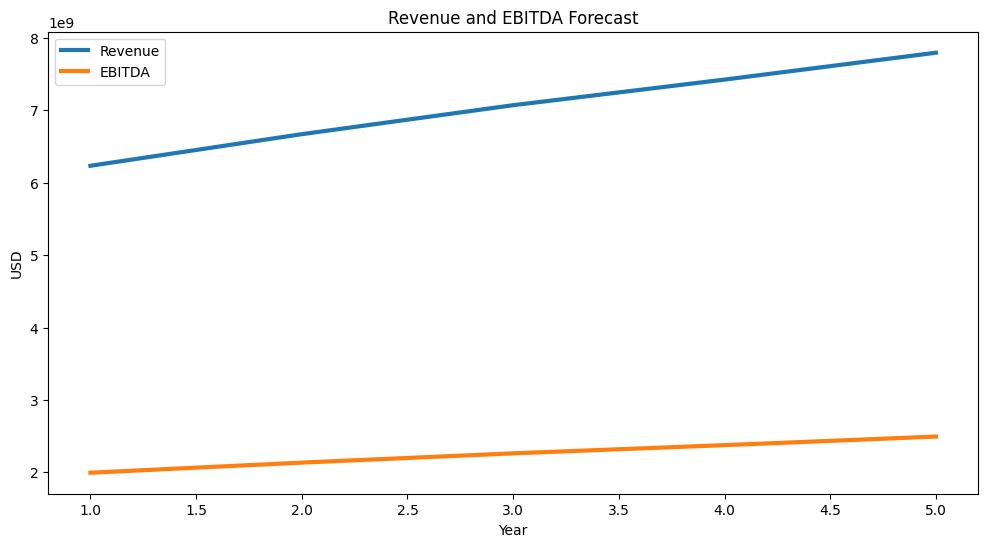

In [90]:
plt.figure(figsize=(12, 6))

plt.plot(forecast_years, forecast_revenue, linewidth=3, label="Revenue")
plt.plot(forecast_years, forecast_ebitda, linewidth=3, label="EBITDA")

plt.title("Revenue and EBITDA Forecast")
plt.xlabel("Year")
plt.ylabel("USD")

plt.legend()

plt.show()

### 13. Debt Paydown Visualization

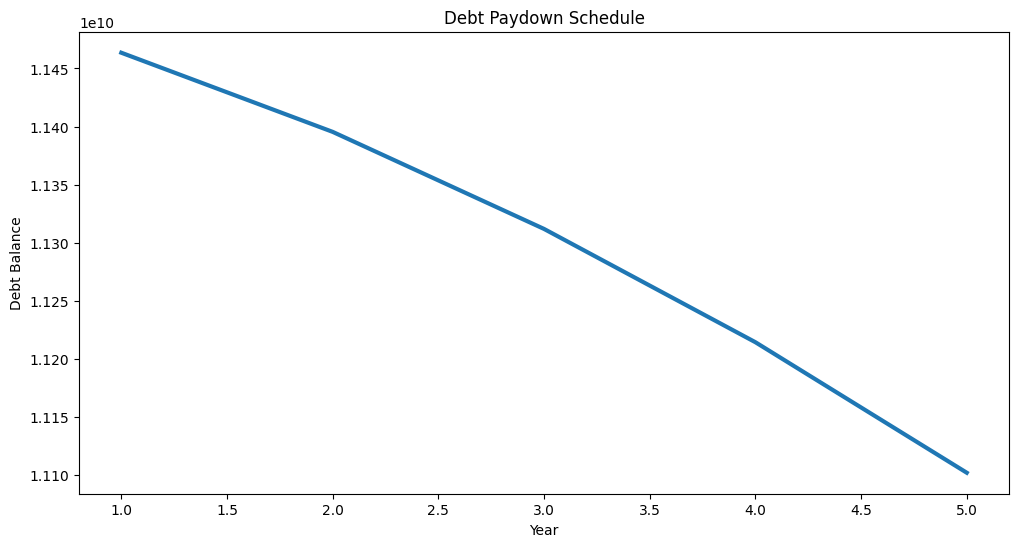

In [91]:
plt.figure(figsize=(12, 6))

plt.plot(forecast_years, forecast_debt, linewidth=3)

plt.title("Debt Paydown Schedule")
plt.xlabel("Year")
plt.ylabel("Debt Balance")

plt.show()

### 14. Sensitivity Analysis

In [92]:
entry_range = np.arange(8, 13, 1)
exit_range = np.arange(8, 13, 1)

sensitivity_matrix = pd.DataFrame(index=entry_range, columns=exit_range)

for entry_multiple in entry_range:

    for exit_multiple in exit_range:
        entry_ev = ebitda * entry_multiple
        entry_equity = entry_ev * (1 - leverage_ratio)
        exit_ev = exit_ebitda * exit_multiple
        exit_equity = exit_ev - remaining_debt_exit
        sensitivity_moic = exit_equity / entry_equity
        sensitivity_matrix.loc[entry_multiple, exit_multiple] = round(sensitivity_moic, 2)

sensitivity_matrix

,8,9,10,11,12
8,2.24,2.87,3.51,4.14,4.77
9,1.99,2.55,3.12,3.68,4.24
10,1.79,2.3,2.8,3.31,3.82
11,1.63,2.09,2.55,3.01,3.47
12,1.49,1.92,2.34,2.76,3.18


### 15. Monte Carlo Simulation

In [93]:
simulation_results = []

num_simulations = 5000

for simulation in range(num_simulations):
    simulated_growth = np.random.normal(0.07, 0.03, holding_period)  # Random revenue growth
    simulated_revenue = revenue

    for growth in simulated_growth:
        simulated_revenue *= (1 + growth)

    simulated_ebitda = simulated_revenue * ebitda_margin

    simulated_exit_ev = simulated_ebitda * exit_ebitda_multiple

    simulated_equity = simulated_exit_ev - remaining_debt_exit

    simulated_moic = simulated_equity / sponsor_equity

    simulation_results.append(simulated_moic)

### 16. Monte Carlo Distribution

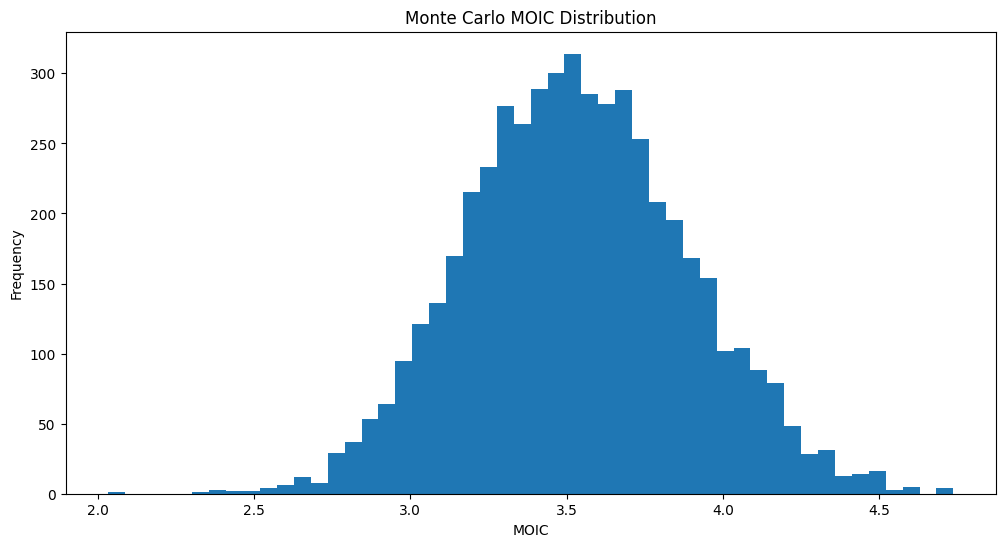

In [94]:
plt.figure(figsize=(12, 6))

plt.hist(simulation_results, bins=50)

plt.title("Monte Carlo MOIC Distribution")
plt.xlabel("MOIC")
plt.ylabel("Frequency")

plt.show()

### 17. Investment Decision Engine

In [95]:
if irr >= 0.25:
    recommendation = "STRONG BUYOUT"
elif irr >= 0.20:
    recommendation = "ATTRACTIVE"
elif irr >= 0.15:
    recommendation = "MODERATE"
else:
    recommendation = "UNATTRACTIVE"

print(f"Recommendation: {recommendation}")

Recommendation: STRONG BUYOUT


### 18. LBO Framework Summary

In [96]:
summary_df = pd.DataFrame({
    "Component": [
        "Revenue Projection",
        "EBITDA Modeling",
        "Debt Schedule",
        "Interest Expense",
        "Free Cash Flow",
        "Exit Multiple",
        "IRR",
        "MOIC",
        "Monte Carlo",
        "Sensitivity Table"
    ],

    "Institutional Equivalent": [
        "Operating Forecast",
        "Cash Earnings Engine",
        "Capital Structure Model",
        "Credit Modeling",
        "Sponsor Cash Generation",
        "Terminal Valuation",
        "Sponsor Return Metric",
        "Private Equity Performance",
        "Probabilistic Scenario Analysis",
        "Sponsor Stress Testing"
    ]
})

summary_df

,Component,Institutional Equivalent
0,Revenue Projection,Operating Forecast
1,EBITDA Modeling,Cash Earnings Engine
2,Debt Schedule,Capital Structure Model
3,Interest Expense,Credit Modeling
4,Free Cash Flow,Sponsor Cash Generation
5,Exit Multiple,Terminal Valuation
6,IRR,Sponsor Return Metric
7,MOIC,Private Equity Performance
8,Monte Carlo,Probabilistic Scenario Analysis
9,Sensitivity Table,Sponsor Stress Testing
